In [1]:
import sys
import subprocess
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data' / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / 'data' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'
EXP_ID = 1
SIGNAL_COL = 'ERKKTR_ratio'

# Generate graph

We've chosen two mutations of the same gene, *PIK3CA*. We think it will be interesting to investigate whether different mutations of the same gene will exhibit similar behaviour. 

In [2]:
MUTATIONS_SITES = {
    "WT": 1,
    "PIK3CA_E545K": 9,
    "PIK3CA_H1047R": 13
}

In [3]:
processes = []

for site_id in MUTATIONS_SITES.values():
    print(f"Starting analysis for site {site_id}...")
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH),
        '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID),
        '--site-id', str(site_id),
        '--signal-col', SIGNAL_COL,
        '--output-dir', str(OUTPUT_ROOT),
    ]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    processes.append((site_id, p))

for site_id, p in processes:
    stdout, stderr = p.communicate()
    print(f"--- Output for site {site_id} ---")
    print(stdout)
    if p.returncode != 0:
        print(f"Error for site {site_id}:\n", stderr)

Starting analysis for site 1...
Starting analysis for site 9...
Starting analysis for site 13...
--- Output for site 1 ---

Spatiotemporal graph analysis complete.
Output directory: /home/plague/Documents/semestr6/biologia_systemow/spatiotemporal-signal-propagation/analysis_outputs/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no di

# Compute $RR$ for each $\tau \in \{0, 1, 2, 3, 4, 5, 6\} $

In [9]:
def compute_RRs_per_site(mutation: str, max_lag: int) -> pd.DataFrame:
    nodes = pd.read_csv(OUTPUT_ROOT / f"exp_{EXP_ID}_site_{MUTATIONS_SITES[mutation]}_{SIGNAL_COL}" / "nodes.csv.gz")
    nodes = nodes.sort_values(['track_id', 'Image_Metadata_T']).reset_index(drop=True)
    results = []

    for tau in range(1, max_lag + 1):
        # shift(tau) within each track: row at position i gets the value from i-tau
        # i.e. "neighbour jump status tau frames ago"
        nodes[f'lagged_exposure_{tau}'] = (
            nodes.groupby('track_id')['neighbor_jump_now']
                .shift(tau)
                .fillna(False)
                .astype(bool)
        )

    for tau in range(max_lag + 1):
        col = 'neighbor_jump_now' if tau == 0 else f'lagged_exposure_{tau}'
        exposed   = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]

        p_exp   = exposed['future_self_jump'].mean()
        p_unexp = unexposed['future_self_jump'].mean()
        rr = p_exp / p_unexp if p_unexp > 0 else np.nan
        rd = p_exp - p_unexp

        results.append({
            'mutation': mutation,
            'site': MUTATIONS_SITES[mutation],
            'tau (frames)': tau,
            'tau (min)':    tau * 5,
            'n_exposed':  len(exposed),
            'p_exp':      round(p_exp, 4),
            'p_unexp':    round(p_unexp, 4),
            'RD':         round(rd, 4),
            'RR':         round(rr, 4),
        })

    df_lag = pd.DataFrame(results)
    return df_lag

In [10]:
MAX_TAU = 6
rr_per_mutation = {mutation: compute_RRs_per_site(mutation, MAX_TAU) for mutation in MUTATIONS_SITES}
df = pd.concat(rr_per_mutation.values()).reset_index(drop=True)
df

,mutation,site,tau (frames),tau (min),n_exposed,p_exp,p_unexp,RD,RR
0,WT,1,0,0,146620,0.1315,0.0749,0.0566,1.7558
1,WT,1,1,5,145714,0.1284,0.0772,0.0513,1.6640
2,WT,1,2,10,144813,0.1248,0.0799,0.0450,1.5627
3,WT,1,3,15,143980,0.1206,0.0829,0.0377,1.4549
4,WT,1,4,20,143194,0.1169,0.0856,0.0313,1.3661
5,WT,1,5,25,142405,0.1136,0.0878,0.0258,1.2940
6,WT,1,6,30,141705,0.1108,0.0898,0.0210,1.2337
7,PIK3CA_E545K,9,0,0,126377,0.1399,0.0860,0.0539,1.6264
8,PIK3CA_E545K,9,1,5,125612,0.1349,0.0894,0.0455,1.5096
9,PIK3CA_E545K,9,2,10,125011,0.1291,0.0931,0.0359,1.3859


#### Save lag table to csv

In [11]:
os.makedirs(PROJECT_ROOT / 'outputs', exist_ok=True)
df.to_csv(PROJECT_ROOT / 'outputs' / 'lagged_exposure_table.csv')

## Table with optimal $\tau$

In [20]:
idx = df.groupby('mutation')['RR'].idxmax()
result = df.loc[idx, ['mutation', 'tau (min)', 'tau (frames)', 'RR']]
result['RR'] = result['RR'].round(4)
result

,mutation,tau (min),tau (frames),RR
7,PIK3CA_E545K,0,0,1.6264
14,PIK3CA_H1047R,0,0,2.8435
0,WT,0,0,1.7558


## Plot $RR$ vs $\tau$

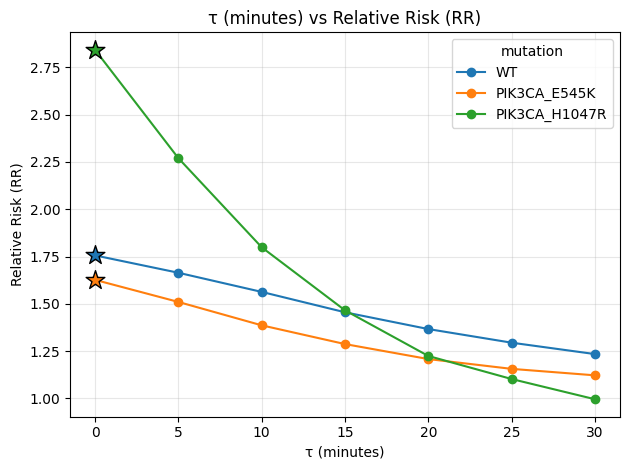

In [15]:
plt.figure()

for m in MUTATIONS_SITES:
    sub = df[df['mutation'] == m].sort_values('tau (min)')
    p = plt.plot(sub['tau (min)'], sub['RR'], marker='o', label=m)
    
    # Mark the optimal tau (maximum RR)
    opt_idx = sub['RR'].idxmax()
    opt_row = sub.loc[opt_idx]
    plt.scatter(opt_row['tau (min)'], opt_row['RR'], color=p[0].get_color(), 
                edgecolor='black', s=200, marker='*', zorder=5, label='_nolegend_')

plt.title('τ (minutes) vs Relative Risk (RR)')
plt.xlabel('τ (minutes)')
plt.ylabel('Relative Risk (RR)')
plt.xticks(sorted(df["tau (min)"].unique()))
plt.legend(title='mutation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretacja

Badanie miało na celu zbadanie wpływu rodzaju mutacji na szybkość rozpowszechniania sygnału pomiędzy wśród komórek. 

Dla mutacji **PIK3CA_E545K**, **PKI3CA_H1047R**, oraz komórek bez mutacji (**WT**) zmierzono ryzyko względne (RR) w zależności od $\tau = (0, 1, 2, 3, 4, 5, 6), co przekłada się na kolejno 0, 5, 10, 15, 20, 25, 30 minut opóźnienia.

Zgodnie z początkowymi przewidywaniami **RR** dla każdej mutacji było największe dla $\tau = 0$, i wraz ze wzrostem $\tau$ **RR** dążyło do 1. 

#### Różnice w zależności RR od $\tau$ pomiędzy mutacjami
Obserwujemy różną dynamikę zmian względnego ryzyka w zależności od opóźnienia. 
W przypadku mutacji **PIK3CA_E545K** tempo zmian jest bardzo zbliżone do tego bez mutacji, występuje tu jedynie zmiana o pewną stałą.

**PIK3CA_H1047R** znacząco zmienił dynamikę zmian **RR** w zależności od $\tau$. 
Może to oznaczać że ta mutacja, mimo że dotyczy tego samego genu, w znacząco inny sposób wpływa na przkazywanie sygnałów.